# Setup and functions

In [1]:
import os
import contextlib
#import stan
import pandas as pd
import math
import numpy as np
import scipy.stats as stats 
from datetime import datetime
import matplotlib.pyplot as plt
import pickle
from scipy.special import softmax
from scipy.stats import norm
import time
import matplotlib.patches as mpatches
import random
from scipy.stats import beta
from pathlib import Path
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors

In [2]:
unmix_optimized = """
data {
int<lower=1> V;                           // number of bins
int<lower=1> K;                           // number of topics
int<lower=1> N;                           // number of observations
array[V] int<lower=0, upper=N> counts_per_bin;    // total number of counts per each one of the V bins (for the optimized version)


// Pre-fitted topic-word matrices for signal and background.
// Each row k is a simplex over V bins: W_c[k, v] = P(bin=v | topic=k, class=c)
array[K] simplex[V] W_signal;
array[K] simplex[V] W_background;

// Priors
vector<lower=0>[K] alpha_signal;          // Dirichlet prior for theta_s
vector<lower=0>[K] alpha_background;      // Dirichlet prior for theta_b
real<lower=0> a_pi;                       // Beta prior parameters for pi
real<lower=0> b_pi;
}

parameters {
simplex[K] theta_signal;                  // topic mixture for the signal component
simplex[K] theta_background;              // topic mixture for the background component
real<lower=0, upper=1> pi;                // fraction of signal in the data
}

transformed parameters {
// Implied per-bin distributions for each component (mixture over topics)
// phi_signal[v] = sum_k theta_signal[k] * W_signal[k, v]
// phi_background[v] = sum_k theta_background[k] * W_background[k, v]
vector<lower=0>[V] phi_signal;
vector<lower=0>[V] phi_background;

for (v in 1:V) {
real acc_s = 0;
real acc_b = 0;
for (k in 1:K) {
acc_s += theta_signal[k] * W_signal[k, v];
acc_b += theta_background[k] * W_background[k, v];
}
phi_signal[v] = acc_s;
phi_background[v] = acc_b;
}
}

model {
// Priors
theta_signal ~ dirichlet(alpha_signal);
theta_background ~ dirichlet(alpha_background);
pi ~ beta(a_pi, b_pi);

for (v in 1:V) {
target += counts_per_bin[v] * log_mix(pi, log(phi_signal[v]), log(phi_background[v]));
}

}

"""

In [3]:
def normalize_prob(x,epsilon=0.0001):
    x = x + epsilon
    x = np.asarray(x, dtype=np.float64)
    s = x.sum(dtype=np.float64)
    y = x / s
    i = y.argmax()                     # adjust the largest to keep all positive
    y[i] += 1.0 - y.sum(dtype=np.float64)
    return y

def flat_histogramdd(df, bins):
    """Receives a dataframe of D dimensions and N datapoints; and a list of how to bin in each one of the D dimensions.
    Returns a flatten historgram with the counting of datapoints in each bin in the D-dimensional grid."""
    cols = df.columns[:len(bins)]
    edges = [np.asarray(b) for b in bins]
    data = df[cols].dropna().to_numpy()
    return np.histogramdd(data, bins=edges)[0].ravel()
    
def generate_ssd(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length, rseed=0, increase=5):
    np.random.seed(rseed)
    count = 0
    means = []
    covs = []
    DF_ssd = []
    Y = []
    [true_mean_x0, true_mean_x1] = [mean_sd[0], mean_sd[1]] # removed the '+ bias' from here
    [[true_sigma, true_covariance], [_, _]] = covariance_sd
    while (count < num_ssd):
        biased_mean_x0 = np.random.normal(true_mean_x0, var)
        biased_mean_x1 = np.random.normal(true_mean_x1+bias, var) # and put it here
        biased_sigma = abs(np.random.normal(true_sigma, var))
        biased_covariance = np.random.normal(true_covariance, var)
        if (((biased_mean_x0 - true_mean_x0)**2 + (biased_mean_x1 - true_mean_x1)**2 > exclusion**2) and # so that here we correctly exclude what we want
            abs(biased_sigma - true_sigma) > exclusion and
            abs(biased_covariance - true_covariance) > exclusion/2 and
            (biased_sigma > 0) and
            (biased_sigma**2 - biased_covariance**2 > 0)):
            if count % 100 ==0: print('Count=', count)
            count += 1
            mean_ssd = [biased_mean_x0, biased_mean_x1]
            covariance_ssd = [[biased_sigma, biased_covariance],
                                         [biased_covariance, biased_sigma]]
            means.append(mean_ssd)
            covs.append(covariance_ssd)
            # Generate more than required, then adjust the required in fiduciary region
            t1 = pd.DataFrame(np.random.multivariate_normal(mean_ssd, covariance_ssd, int(increase*ssd_length)), 
                columns=['x'+str(s) for s in range(len(mean_sd))])
            t1 = t1[(t1['x0'] >= min(mybinning[0])) & (t1['x0'] < max(mybinning[0])) & (t1['x1'] >= min(mybinning[1])) & (t1['x1'] < max(mybinning[1]))]
            t1 = t1.head(ssd_length).reset_index(drop=True).copy()
            if (len(t1)) != ssd_length: print('Error in length: SSD #',count,'has',len(t1),'events and it should have', ssd_length)
            
            DF_ssd.append(t1)
            t2 = normalize_prob(flat_histogramdd(t1,mybinning))
            Y.append(list(t2))
        
    return DF_ssd, np.array(Y)

def generate_sd(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns, Nb, rseed=0, mybinning=[[],[]], plotit=0):
    increase = 5 # factor to increase data such that the data in the fiducial region ends up being what was requested
    np.random.seed(rseed)
    sd_signal_tmp = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,int(increase*Ns)),
        columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    sd_background_tmp = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_background, covariance_sd_background,int(increase*Nb)),
        columns = ['x'+str(s) for s in range(len(mean_sd_background))])
    mask_signal = (sd_signal_tmp['x0'] >= min(mybinning[0])) & (sd_signal_tmp['x0'] < max(mybinning[0])) & (sd_signal_tmp['x1'] >= min(mybinning[1])) & (sd_signal_tmp['x1'] < max(mybinning[1]))
    mask_background = (sd_background_tmp['x0'] >= min(mybinning[0])) & (sd_background_tmp['x0'] < max(mybinning[0])) & (sd_background_tmp['x1'] >= min(mybinning[1])) & (sd_background_tmp['x1'] < max(mybinning[1]))
    sd_signal = sd_signal_tmp.loc[mask_signal].head(Ns).reset_index(drop=True).copy()
    sd_background = sd_background_tmp.loc[mask_background].head(Nb).reset_index(drop=True).copy()
    
    if len(sd_background) != Nb: print('Atention, background length is: '+str(len(sd_background)) )
    if len(sd_signal) != Ns: print('Atention, signal length is: '+str(len(sd_signal)) )

    # np.random.seed(rseed)
    # sd_signal = pd.DataFrame(
    #     np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,Ns),
    #     columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    # sd_background = pd.DataFrame(
    #     np.random.multivariate_normal(mean_sd_background, covariance_sd_background,Nb),
    #     columns = ['x'+str(s) for s in range(len(mean_sd_background))])
    
    if plotit==1:
        plt.scatter(sd_background['x0'],sd_background['x1'], s=1, label='Background')
        plt.scatter(sd_signal['x0'],sd_signal['x1'], s=2, label='Signal')
        plt.xlim(mybinning[0][0],mybinning[0][-1])
        plt.ylim(mybinning[1][0],mybinning[1][-1])
        for vline in mybinning[0]:
            plt.axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
        for hline in mybinning[1]:
            plt.axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
        plt.legend()
        plt.show()

    print("Lengths:", len(sd_signal), len(sd_background) )
    #### Data as a whole
    sd_data = pd.concat([sd_signal, sd_background])
    # Shuffle the merged DataFrame in place
    sd_data = sd_data.sample(frac=1).reset_index(drop=True)
    
    sd_data_hist  = flat_histogramdd(sd_data, mybinning)

    pi_true_in_fiduciary = sum(flat_histogramdd(sd_signal, mybinning)) / sum(flat_histogramdd(sd_data, mybinning))
    # For the sake of the inference problem, we better have the data as events, where each event is the bin number
    bins = [x-0.5 for x in range(len(sd_data_hist))]  # Bin edges
    frequencies = sd_data_hist  # Frequencies in each bin
    
    sd_data_hist1 = []
    for bin_edge, freq in zip(bins, frequencies):
        sd_data_hist1.extend([bin_edge+0.5] * int(freq))
        
    
    X0 = sd_data_hist
    # This is our data!!!! (we start with bin=1 because of STAN that starts counting on 1 and not on 0)
    X = [int(x+1) for x in sd_data_hist1]
    np.random.shuffle(X)
    return X, sd_signal, sd_background, pi_true_in_fiduciary

def unmix_data_optimized(data_unmix_optimized, num_samples, num_warmup, delta, random_seed=0, plot_it=1):
    model_unmix = stan.build(unmix_optimized, data=data_unmix_optimized, random_seed=random_seed)
    #control={'stepsize': 0.01, 'adapt_delta': 0.95}
    #fit_unmix = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=delta, stepsize=0.001, max_depth=15, refresh=0);
    fit_unmix = model_unmix.sample(num_chains=4, num_samples=num_samples, num_warmup=num_warmup, delta=delta, refresh=0);
    samples_unmix = fit_unmix.to_frame() 
    samples_unmix.sort_values(by='lp__', inplace=True, ascending=False)
    #

    # Let's diagnose the inference, we plot Rhat to assess chains convergence
    azdata = az.from_pystan(fit_unmix)
    summary = az.summary(azdata)
    tmp = summary['r_hat']
    if plot_it==1:
        print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
        plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
        plt.show()
        return samples_unmix, summary
    else:
        return samples_unmix, [np.min(tmp), np.max(tmp), np.mean(tmp), np.std(tmp)]

def convert(list_of_dataframes, mybinning):
    #convert all SSD signal events into 3 lists to feed the LDA model
    cnt = []
    v_idx = []
    pos = [1]
    for i in range(len(list_of_dataframes)):
        counts = flat_histogramdd(list_of_dataframes[i], mybinning)
        int_counts = counts.astype(int)
        # for i in range(len(int_counts)):   ## Yo, here index i it was repeated inside he loop!!!
        #     v_idx.append(i+1)
        #     cnt.append(int_counts[i])
        for j in range(len(int_counts)):
            v_idx.append(j+1)
            cnt.append(int_counts[j])
        pos.append(pos[-1]+len(int_counts))
    return cnt, v_idx, pos

def unmix_data(data_unmix, num_samples, num_warmup, delta, random_seed=0, plot_it=1):
    model_unmix = stan.build(unmix, data=data_unmix, random_seed=random_seed)
    #control={'stepsize': 0.01, 'adapt_delta': 0.95}
    #fit_unmix = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=delta, stepsize=0.001, max_depth=15, refresh=0);
    fit_unmix = model_unmix.sample(num_chains=4, num_samples=num_samples, num_warmup=num_warmup, delta=delta, refresh=0);
    samples_unmix = fit_unmix.to_frame() 
    samples_unmix.sort_values(by='lp__', inplace=True, ascending=False)
    #

    # Let's diagnose the inference, we plot Rhat to assess chains convergence
    azdata = az.from_pystan(fit_unmix)
    summary = az.summary(azdata)
    tmp = summary['r_hat']
    if plot_it==1:
        print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
        plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
        plt.show()
        return samples_unmix, summary
    else:
        return samples_unmix, [np.min(tmp), np.max(tmp), np.mean(tmp), np.std(tmp)]


def credible_interval_hdi(samples, mass):
    x = np.sort(np.asarray(samples))
    n = x.size
    if n == 0:
        raise ValueError("Empty sample.")
    k = int(np.floor(mass * n))
    if k < 1:
        raise ValueError("Not enough samples for requested mass.")
    widths = x[k:] - x[:-k]  # a list of all the possible widths with int(mass * n) events in the middle (it is a difference of np arrays)
    i = np.argmin(widths)
    return (x[i], x[i + k])

def coveragexn(steps, d, text=' ' ):
    for step in steps:
        x_grid = np.linspace(0, 1, 10000)
        mean_widths = np.mean(d[step][1])
    
        aa = sum(d[step][0])
        bb = len(d[step][0]) - aa
        
        # mean of Beta
        mean = 1.0* aa / (aa + bb)
        
        # central 95% interval (16th and 84th percentiles)
        ci = 0.95
        alpha = (1.0 - ci) / 2.0
        lower_central = beta.ppf(alpha, aa, bb)
        upper_central = beta.ppf(1.0 - alpha, aa, bb)
        d[step][2] = [step, mean, lower_central,upper_central, mean_widths]
    return d

def area(x,mean_y, lower_y, upper_y):
    for i in range(len(lower_y)):
        if np.isnan(lower_y[i]): lower_y[i] = mean_y[i]
    for i in range(len(upper_y)):
        if np.isnan(upper_y[i]): upper_y[i] = mean_y[i]
        
    mean_tot = 0
    for i in range(len(x)-1):
        mean_tot += (x[i+1]-x[i]) * (mean_y[i] + mean_y[i+1]) / 2

    lower_tot = 0
    for i in range(len(x)-1):
        lower_tot += (x[i+1]-x[i]) * (lower_y[i] + lower_y[i+1]) / 2

    upper_tot = 0
    for i in range(len(x)-1):
        upper_tot += (x[i+1]-x[i]) * (upper_y[i] + upper_y[i+1]) / 2
        
    return np.round(mean_tot,3), np.round(upper_tot-mean_tot,3), np.round(mean_tot-lower_tot,3)

### Following function is to estimate K topics and V bins given the desired r1 and r2


def solve_KV(M, r1, r2, tol=1e-12):
    """
    Solve the system for K and V given numeric M, r1, r2.
    Returns a list of (K, V) pairs where both K and V are real and > 0.
    """
    sols = []

    # handle r2 == 0 as a special case: 2(K-1)+1 = 0 => K = 1/2
    if abs(r2) <= tol:
        K = 0.5
        denom = K - r1 * M
        if abs(denom) > tol:
            V = 1.0 - M * (K - 1.0) / denom
            if V > 0 and K > 0:
                sols.append((float(K), float(V)))
        return sols

    # coefficients of quadratic 2 K^2 + B K + C = 0
    B = r2 * M - 2.0 * r1 * M - 1.0
    C = r1 * M - r2 * M
    D = B * B - 8.0 * C  # discriminant

    if D < -tol:
        return sols  # no real roots
    if D < 0:
        D = 0.0

    sqrtD = math.sqrt(D)
    for sign in (+1.0, -1.0):
        K = (-B + sign * sqrtD) / 4.0  # divide by 2*A where A=2 -> 4
        # compute V from second equation: V = 1 + (2K-1)/r2
        V = 1.0 + (2.0 * K - 1.0) / r2
        # keep only real positive solutions
        if (not math.isfinite(K)) or (not math.isfinite(V)):
            continue
        if K > 0 and V > 0:
            sols.append((float(K), float(V)))

    # remove duplicates (possible when D == 0)
    unique = []
    for s in sols:
        if all(abs(s[0]-u[0])>1e-9 or abs(s[1]-u[1])>1e-9 for u in unique):
            unique.append(s)

    print('Solutions as (K,V):')
    return unique

# Example usage:
# print(solve_KV(1.0, 0.1, 0.3))

In [4]:
# DiHiggs functions

def generate_sd_physical(Ns, Nb, mybinning=[[],[]], rseed=0, plotit=0):  
    # Import the full SS datasets for signal and background
    increase = 4 # factor to increase data such that he data in the fiducial region ends up being what was requested
    path_signal = Path('data') / 'dihiggs_sd_processed.dat'
    path_background = Path('data') / 'bbbb_sd_combined_processed_feb_12.dat'
    sd_signal = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    sd_background = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    # Select the required number of events
    sd_signal = sd_signal.sample(n=int(increase*Ns), random_state=rseed).reset_index(drop=True) 
    sd_background = sd_background.sample(n=int(increase*Nb), random_state=rseed).reset_index(drop=True) 
    mask_signal = (sd_signal['x0'] > mybinning[0][0]) & (sd_signal['x0'] < mybinning[0][-1]) & (sd_signal['x1'] > mybinning[1][0]) & (sd_signal['x1'] < mybinning[1][-1])
    mask_background = (sd_background['x0'] > mybinning[0][0]) & (sd_background['x0'] < mybinning[0][-1]) & (sd_background['x1'] > mybinning[1][0]) & (sd_background['x1'] < mybinning[1][-1])
    sd_signal = sd_signal.loc[mask_signal].head(Ns).reset_index(drop=True).copy()
    sd_background = sd_background.loc[mask_background].head(Nb).reset_index(drop=True).copy()

    if len(sd_background) < Nb: print('Atention, background length is: '+str(len(sd_background)) )
    if len(sd_signal) < Ns: print('Atention, signal length is: '+str(len(sd_signal)) )

    if plotit==1:
        plt.scatter(sd_signal['x0'],sd_signal['x1'], s=0.5)
        plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5)
        for vline in mybinning[0]:
            plt.axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
        for hline in mybinning[1]:
            plt.axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
        plt.show()
        
    #### Data as a whole
    sd_data = pd.concat([sd_signal, sd_background])
    # Shuffle the merged DataFrame in place
    sd_data = sd_data.sample(frac=1).reset_index(drop=True)
    
    sd_data_hist  = flat_histogramdd(sd_data, mybinning)
    
    # For the sake of the inference problem, we better have the data as events, where each event is the bin number
    bins = [x-0.5 for x in range(len(sd_data_hist))]  # Bin edges
    frequencies = sd_data_hist  # Frequencies in each bin
    
    sd_data_hist1 = []
    for bin_edge, freq in zip(bins, frequencies):
        sd_data_hist1.extend([bin_edge+0.5] * int(freq))
        
    
    X0 = sd_data_hist
    # This is our data!!!! (we start with bin=1 because of STAN that starts counting on 1 and not on 0)
    X = [int(x+1) for x in sd_data_hist1]
    np.random.shuffle(X)
    return X, sd_signal, sd_background, len(sd_signal)/ (len(sd_signal)+len(sd_background))

def generate_ssd_physical_signal(mybinning, num_ssd, ssd_length, rseed=0):
    # We leave the arguments equal, even though most of them we don't use them.  Just to leave input and output qith the same structure.
    # SSD
    DF_ssd = []
    Y = []
    n = 1 # start in n=1 because of the filenames
    while (n<num_ssd+1): 
        if n % 100 == 0: print('Count =',n)
        path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'      
        t1 = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
        t1 = t1.sample(n=ssd_length, random_state=rseed).reset_index(drop=True)
        #path_background = Path('data') / 'background_ssds_processed' / f'bbbb_ssd_{n}.dat'
        #df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['col1', 'col2'])
        DF_ssd.append(t1)
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        Y.append(list(t2))
        n += 1
    
    return DF_ssd, np.array(Y)

def generate_ssd_physical_background(mybinning, num_ssd, ssd_length, rseed=0):
    # We leave the arguments equal, even though most of them we don't use them.  Just to leave input and output qith the same structure.
    # SSD
    DF_ssd = []
    Y = []
    n = 1
    while (n<num_ssd+1): 
        if n % 100 == 0: print('Count =',n)
        path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'
        t1 = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
        t1 = t1.sample(n=ssd_length, random_state=rseed).reset_index(drop=True)
        DF_ssd.append(t1)
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        Y.append(list(t2))
        n += 1
    
    return DF_ssd, np.array(Y)

In [5]:
def moving_average(arr, n, axis=0):
    """Return array smoothed by a symmetric moving average of radius n along `axis`.
    Edges use the available samples (window shrinks)."""
    arr = np.asarray(arr)
    if n <= 0:
        return arr.copy()
    kernel = np.ones(2 * n + 1, dtype=float)
    def _smooth_1d(v):
        v = v.astype(float)
        num = np.convolve(v, kernel, mode='same')
        denom = np.convolve(np.ones_like(v), kernel, mode='same')
        return num / denom
    return np.apply_along_axis(_smooth_1d, axis, arr)

In [6]:
cmap = plt.cm.viridis
n_components = [2,3,4,5,6,7,8]
colors = [cmap(0.15 + 0.75 * i / (len(n_components) - 1)) for i in range(len(n_components))]

def create_curves(pi_collection, pi_true):
    steps = np.linspace(0.01,0.99,80)
    d = {step: [[],[],[]] for step in steps}
    pp = pi_collection[:]  # Make a shallow copy
    random.shuffle(pp)     # Shuffle in place
    for i in range(int(len(pp)/1)):
        for step in steps:
            inf, sup = credible_interval_hdi(pp[i]["pi"],step)
            if pi_true > inf and pi_true < sup:
                d[step][0].append(1)
            else:
                d[step][0].append(0)
            d[step][1].append(sup-inf)
    
    dd = coveragexn(steps,d)
    # gather data from dd and steps
    x = np.array([dd[step][2][0] for step in steps])
    mean_y = np.array([dd[step][2][1] for step in steps])
    lower_y = np.array([dd[step][2][2] for step in steps])
    upper_y = np.array([dd[step][2][3] for step in steps])
    return x, moving_average(mean_y,3), moving_average(lower_y,3), moving_average(upper_y,3)

# Plots

## Gaussian case study

### Data distiribution @Gaussian

In [7]:
mybinning = [np.linspace(-2,2,11),np.linspace(-2,2,11)] #fiduciary region only
mybinning_extended = [np.linspace(-4,4,11),np.linspace(-4,4,11)]
#mybinning = [np.concatenate((np.linspace(-6,-4,2),np.linspace(-2,2,11),np.linspace(4,6,2))),np.concatenate((np.linspace(-6,-4,2),np.linspace(-2,2,11),np.linspace(4,6,2)))]

## Define target and biased parameters for signal and background
mean_sd_signal = [0, 0]
covariance_sd_signal = [[1, 0], [0, 1]]
mean_sd_background = [0, 1]
covariance_sd_background = [[3, 0.4], [0.4, 3]]
# Exclusion algorithm
exclusion = 0.1
var = 0.1
bias_signal = -0.1
bias_bkg = +0.1

## Define TD parameters
Ns = 1000
Nb = 10000

## Define SSD parameters
ssd_length = max(Ns,Nb)*8
Nssd_signal = 500
Nssd_background = 500

## Number of topics
V = (len(mybinning[0])-1) * (len(mybinning[1])-1) # number of bins
rseed=0
plotit=0
X, sd_signal, sd_background, pi_true_in_fiduciary = generate_sd(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns, Nb, mybinning=mybinning_extended, rseed=rseed, plotit=plotit)


Lengths: 1000 10000


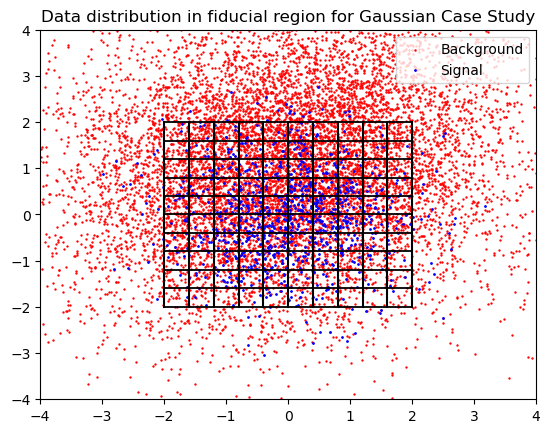

In [9]:
plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5, color='red', label='Background')
plt.scatter(sd_signal['x0'],sd_signal['x1'], s=1, color='blue', label='Signal')
plt.xlim(mybinning_extended[0][0],mybinning_extended[0][-1])
plt.ylim(mybinning_extended[1][0],mybinning_extended[1][-1])
for hline in mybinning[1]:
    plt.plot([mybinning[0][0],mybinning[0][-1]], [hline, hline], linewidth=1.3, linestyle='solid', color='black')
for vline in mybinning[1]:
    plt.plot([vline,vline],[mybinning[1][0],mybinning[1][-1]], linewidth=1.5, linestyle='solid', color='black')
plt.title('Data distribution in fiducial region for Gaussian Case Study')
plt.legend(loc=1)
plt.savefig('figs/data_distribution_gaussian.pdf', bbox_inches='tight', pad_inches=0.2)

plt.show()

### Kappa distribution @toy

In [10]:
K2 = 20
fname = f"results/pi_collection-toy-model.fiduciary-20-topics-varying.20260319_150616rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_20 = pickle.load(f)

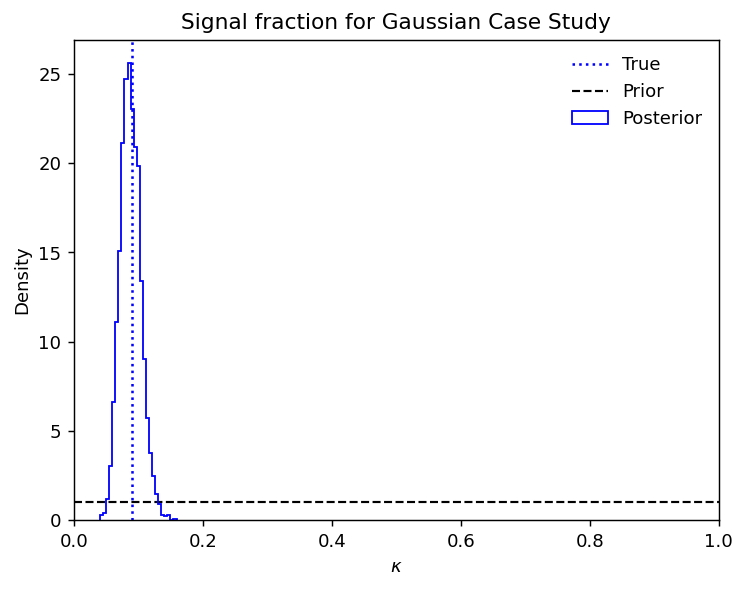

In [11]:
pi_true = 5000/55000
plt.figure(dpi=130)
plt.axvline(x=pi_true, color='blue', linestyle='dotted', linewidth=1.4, label='True', zorder=0)
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1.2, label='Prior', zorder = 1)
plt.hist(pi_collection_20[2]['pi'], bins=25, histtype='step', density=1, color='blue', label='Posterior', zorder=2)
plt.xlim(0,1)
plt.xlabel('$\\kappa$')
plt.ylabel('Density')
plt.title('Signal fraction for Gaussian Case Study') 
plt.legend(frameon=False)
plt.savefig('figs/signal-fraction_gaussian.pdf')
#plt.yticks([])
plt.show()

### Coverage plot @Gaussian

In [12]:
K2 = 4
fname = f"results/pi_collection-toy-model.fiduciary-4-topics-varying.20260319_150416rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_4 = pickle.load(f)

In [13]:
K2 = 20
fname = f"results/pi_collection-toy-model.fiduciary-20-topics-varying.20260319_150616rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_20 = pickle.load(f)

In [14]:
K2 = 50
runname = "20260308_022600"  # set to the same runname used when saving
fname = f"results/pi_collection-toy-model.fiduciary-{K2}-topics.{runname}.pickle"
fname = f"results/pi_collection-toy-model.fiduciary-50-topics-varying.20260319_212249rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_50 = pickle.load(f)

In [15]:
K2 = 100
runname = "20260308_025717"  # set to the same runname used when saving
fname = f"results/pi_collection-toy-model.fiduciary-{K2}-topics.{runname}.pickle"
fname = f"results/pi_collection-toy-model.fiduciary-100-topics-varying.20260319_213924rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_100 = pickle.load(f)

In [16]:
cmap = plt.cm.viridis
n_components = [2,3,4,5,6,7,8]
colors = [cmap(0.15 + 0.75 * i / (len(n_components) - 1)) for i in range(len(n_components))]

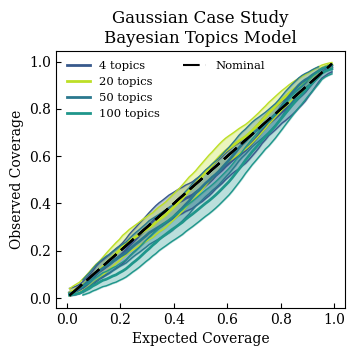

In [17]:
plt.rcParams.update({'text.usetex': False, 'font.family': 'serif'})
pi_true = 0.09090909090909091
fig, axes = plt.subplots(figsize=(3.5,3.5))
# 4 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_4, pi_true)
i = 1  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='4 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)


#20 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_20, pi_true)
i = 6  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='20 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

#50 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_50, pi_true)
i = 2  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='50 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

#100 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_100, pi_true)
i = 3  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='100 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

# Final details
axes.plot(x, x, color='black', linestyle=(0, (8, 3)), linewidth=1.5, label='Nominal')
axes.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes.set_ylabel("Observed Coverage")
axes.set_xlabel("Expected Coverage")
axes.tick_params(axis='both', which='both', direction='in')
handles, labels = axes.get_legend_handles_labels()
blank = mpatches.Patch(color='none', label='')
handles += [blank] * 2
labels += [''] * 2
axes.legend(handles, labels, ncol=2, frameon=False, fontsize='small')

axes.set_title('Gaussian Case Study\nBayesian Topics Model')
#ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.2),
#frameon=True, fancybox=True, framealpha=1.0, handlelength=3, fontsize='medium')
fig.tight_layout(pad=0.5)
fig.savefig('figs/coverage_gaussian.topics.pdf', bbox_inches='tight', pad_inches=0.2)
plt.show()

### kappa pull-sigma for true = fixed = 0.09 @Gaussian

In [18]:
K2 = 20
fname="results/pi_collection-toy-model.fiduciary-20-topics-varying.20260320_002809rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_20_seed_1 = pickle.load(f)

print(len(pi_collection_20_seed_1))

900


In [19]:
pi_true = 5000 / 55000
out = []
for i in range(len(pi_collection_20_seed_1)):
    tmp = list(credible_interval_hdi(pi_collection_20_seed_1[i]['pi'],0.68))
    hdi68 = tmp[1]-tmp[0]
    tmp = list(credible_interval_hdi(pi_collection_20_seed_1[i]['pi'],0.10))
    map_marginalized = (tmp[1]+tmp[0])/2
    map_full = pi_collection_20_seed_1[i].iloc[0]['pi']
    pull = (map_full - pi_true) / (hdi68/2)
    pull2 = (map_marginalized - pi_true) / (hdi68/2)
    out.append([hdi68, map_marginalized, map_full, pull, pull2])

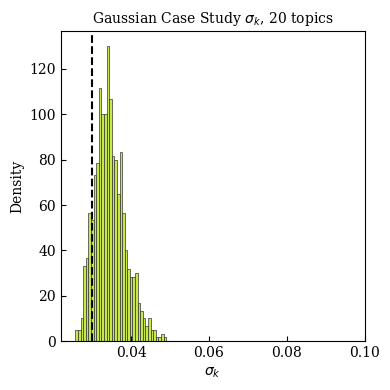

In [20]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.hist([x[0] for x in out], bins=35, color='#c7e74a', edgecolor='#333333', linewidth=0.5, density=True)
ax.axvline(0.03, color='k', linestyle='--', linewidth=1.5)  # change 0.03 if needed

ax.set_xlabel(r'$\sigma_k$')
ax.set_ylabel('Density')
ax.set_title('Gaussian Case Study $\\sigma_k$, 20 topics', fontsize=10)
ax.tick_params(axis='both', which='both', direction='in')
ax.set_xlim(0.022, 0.1)
#ax.set_yticks([])  

plt.tight_layout()
#plt.savefig('figs/gaussian_uncertainties.topicsmodel.pdf')
plt.show()

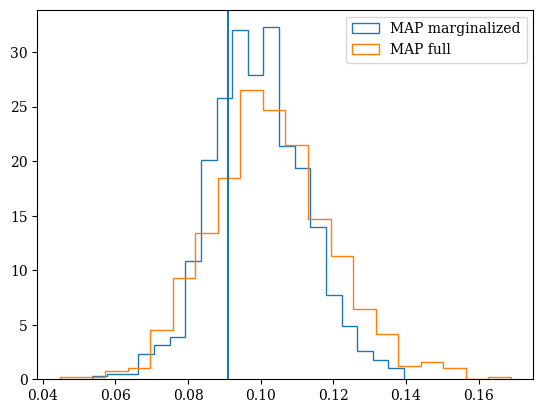

In [21]:
plt.hist([x[1] for x in out], histtype='step', density=1, bins=20, label='MAP marginalized')
plt.hist([x[2] for x in out], histtype='step', density=1, bins=20, label='MAP full')
plt.axvline(pi_true)
plt.legend()
plt.show()

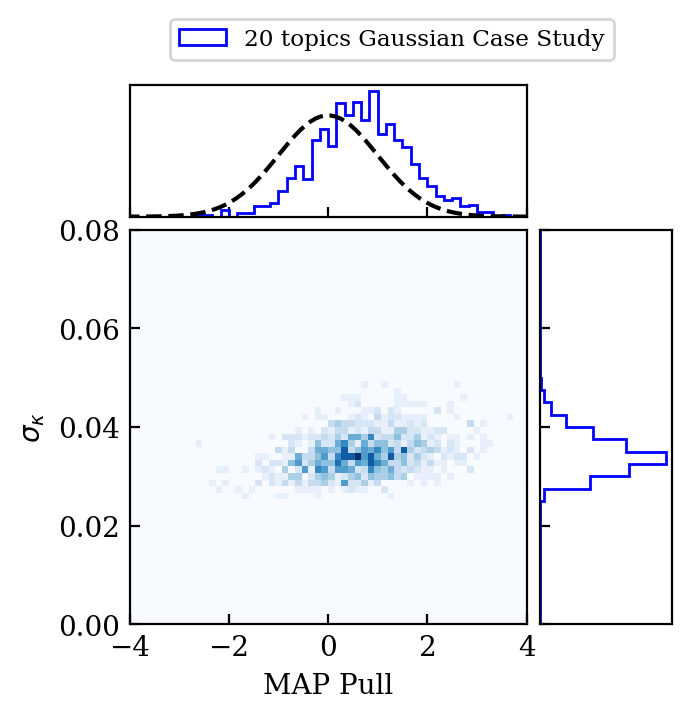

In [22]:
# Sample data

cmap = plt.cm.Blues.copy()
cmap.set_under("white")

x = [x[3] for x in out]
y = [x[0] for x in out]
# x_baseline = (torch.stack(baseline_consolidated_preds_list).flatten().numpy()-0.1)/torch.stack(baseline_consolidated_uncs_list).flatten().numpy()
# y_baseline = torch.stack(baseline_consolidated_uncs_list).flatten().numpy()

fig, axs = plt.subplot_mosaic(
    [["histx", "."],
     ["joint", "histy"]],
        figsize=(3.5, 3.5),
    width_ratios=[3, 1],
    height_ratios=[1, 3],
    gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    dpi=200
)

# 2D histogram

axs["joint"].hist2d(x, y, bins=60, cmap=cmap, range=[[-4, 4], [0, 0.08]])
axs["joint"].set_xlabel('MAP Pull')
axs["joint"].set_ylabel(f"$\sigma_\kappa$")
axs["joint"].tick_params(which='both', direction='in')

# Marginals
axs["histx"].hist(x, bins=60, color="blue", range=(-5, 5), density=True, histtype='step', label=f"{K2} topics Gaussian Case Study")#\nTrue = 0.09 (fixed)")
#axs["histx"].hist(x_baseline, bins=60, color="black", range=(-5, 5), density=True, label="Baseline", histtype='step')
axs["histx"].plot(np.linspace(-5, 5, 100), norm.pdf(np.linspace(-5, 5, 100)), color="black", linestyle="--")#, label="Standard Normal")
axs["histx"].sharex(axs["joint"])
axs["histx"].tick_params(labelbottom=False, direction='in')
axs["histx"].set_yticks([])

axs["histy"].hist(y, bins=60, orientation="horizontal", color="blue", range=(0, 0.15), density=True, histtype='step')
#axs["histy"].hist(y_baseline, bins=60, orientation="horizontal", color="black", range=(0, 0.15), density=True, label="Baseline", histtype='step')

axs["histy"].sharey(axs["joint"])
axs["histy"].tick_params(labelleft=False, direction='in')
axs["histy"].set_xticks([])

handles, labels = axs["histx"].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, .9), frameon=True, fontsize='small', columnspacing=1.0)

fig.savefig('figs/pull-sigma_gaussian.pdf', bbox_inches='tight', pad_inches=0.2)
plt.show()

 



### kappa pull-sigma for true ~ prior @Gaussian

In [23]:
K2 = 20
fname = f"results/pi_collection-toy-model.fiduciary-20-varying-topics.unbiased-parameter-estimation.20260319_234917rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_10_seed_1 = pickle.load(f)

print(len(pi_collection_10_seed_1))

900


In [24]:
out = []
for i in range(len(pi_collection_10_seed_1)):
    pi_true = pi_collection_10_seed_1[i][1]
    tmp = list(credible_interval_hdi(pi_collection_10_seed_1[i][0]['pi'],0.68))
    hdi68 = tmp[1]-tmp[0]
    tmp = list(credible_interval_hdi(pi_collection_10_seed_1[i][0]['pi'],0.10))
    map_marginalized = (tmp[1]+tmp[0])/2
    map_full = pi_collection_10_seed_1[i][0].iloc[0]['pi']
    pull = (map_full - pi_true) / (hdi68/2)
    pull2 = (map_marginalized - pi_true) / (hdi68/2)
    out.append([hdi68, map_marginalized, map_full, pull, pull2])

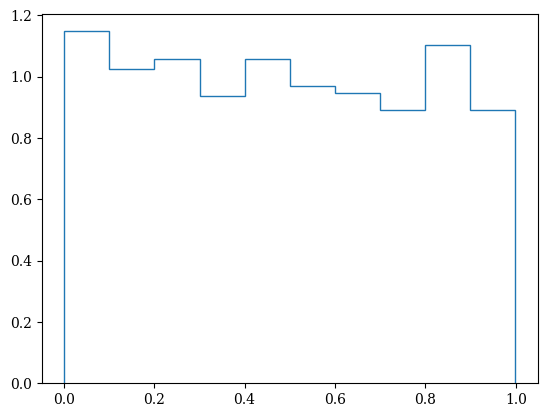

In [25]:
plt.hist([pi_collection_10_seed_1[i][1] for i in range(len(pi_collection_10_seed_1))], density=1, histtype='step')
plt.show()

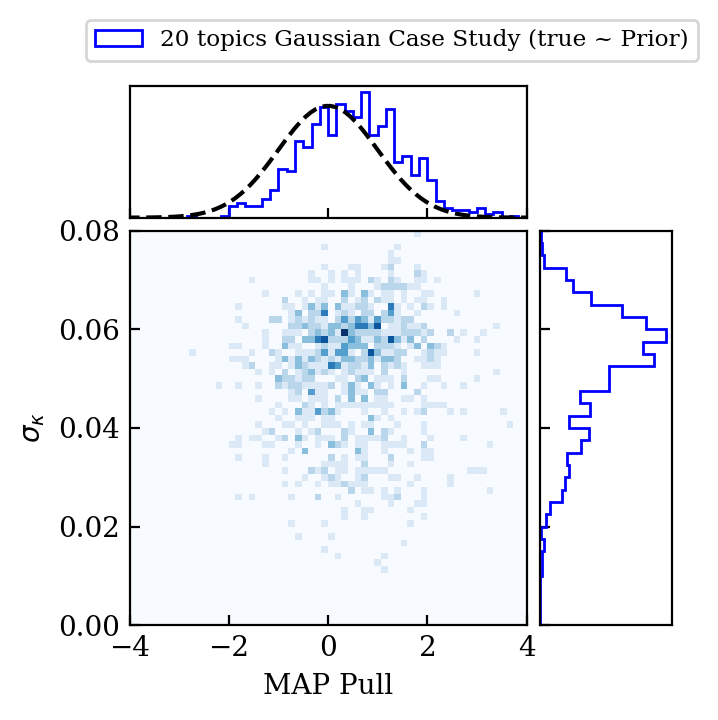

In [26]:
# Sample data

cmap = plt.cm.Blues.copy()
cmap.set_under("white")

x = [x[3] for x in out]
y = [x[0] for x in out]
# x_baseline = (torch.stack(baseline_consolidated_preds_list).flatten().numpy()-0.1)/torch.stack(baseline_consolidated_uncs_list).flatten().numpy()
# y_baseline = torch.stack(baseline_consolidated_uncs_list).flatten().numpy()

fig, axs = plt.subplot_mosaic(
    [["histx", "."],
     ["joint", "histy"]],
        figsize=(3.5, 3.5),
    width_ratios=[3, 1],
    height_ratios=[1, 3],
    gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    dpi=200
)

# 2D histogram

axs["joint"].hist2d(x, y, bins=60, cmap=cmap, range=[[-4, 4], [0, 0.08]])
axs["joint"].set_xlabel("MAP Pull")
axs["joint"].set_ylabel(f"$\sigma_\kappa$")
axs["joint"].tick_params(which='both', direction='in')

# Marginals
axs["histx"].hist(x, bins=60, color="blue", range=(-5, 5), density=True, histtype='step', label=f"{K2} topics Gaussian Case Study (true ~ Prior)")
#axs["histx"].hist(x_baseline, bins=60, color="black", range=(-5, 5), density=True, label="Baseline", histtype='step')
axs["histx"].plot(np.linspace(-5, 5, 100), norm.pdf(np.linspace(-5, 5, 100)), color="black", linestyle="--")#, label="Standard Normal")
axs["histx"].sharex(axs["joint"])
axs["histx"].tick_params(labelbottom=False, direction='in')
axs["histx"].set_yticks([])

axs["histy"].hist(y, bins=60, orientation="horizontal", color="blue", range=(0, 0.15), density=True, histtype='step')
#axs["histy"].hist(y_baseline, bins=60, orientation="horizontal", color="black", range=(0, 0.15), density=True, label="Baseline", histtype='step')

axs["histy"].sharey(axs["joint"])
axs["histy"].tick_params(labelleft=False, direction='in')
axs["histy"].set_xticks([])

handles, labels = axs["histx"].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, .9), fontsize='small', columnspacing=1.0)

fig.savefig('figs/pull-sigma-gaussian.true-prior.pdf', bbox_inches='tight', pad_inches=0.2)
plt.show()

 



### Hellinger distances @toy

In [27]:
K2 = 20
fname = f"results/hellinger-data-toy-20-topics.20260320_002809rseed=1.pickle"
with open(fname, 'rb') as f:
    hellinger_distances = pickle.load(f)

In [28]:
[sd_signal, sd_background, mybinning, samples_unmix, Ys, Yb] = hellinger_distances
V = (len(mybinning[0])-1)*(len(mybinning[1])-1)

In [29]:
signal_true = normalize_prob(flat_histogramdd(sd_signal,mybinning))
background_true = normalize_prob(flat_histogramdd(sd_background,mybinning))

# Posterior Hellinger distances to true
signal_hellingers = []
background_hellingers = []
for draw in range(len(samples_unmix)):
    tmp_s = []
    tmp_b = []
    for j in range(1,V+1):
        tmp_s.append(samples_unmix.iloc[draw]['phi_signal.'+str(j)])
        tmp_b.append(samples_unmix.iloc[draw]['phi_background.'+str(j)])
    signal_draw = np.array(tmp_s)
    background_draw = np.array(tmp_b)
    signal_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(signal_true)-np.sqrt(signal_draw))**2)))
    background_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(background_true)-np.sqrt(background_draw))**2)))

# Prior Hellinger distances to true
signal_prior_hellingers = []
background_prior_hellingers = []
for ssd in range(len(Ys)):
    #signal_prior_hellingers.append(np.sum((np.sqrt(signal_true)-np.sqrt(Ys[ssd]))**2))
    signal_prior_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(signal_true) - np.sqrt(Ys[ssd]))**2)))
for ssd in range(len(Yb)):
    background_prior_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(background_true)-np.sqrt(Yb[ssd]))**2)))


/tmp/ipykernel_364359/3256162876.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


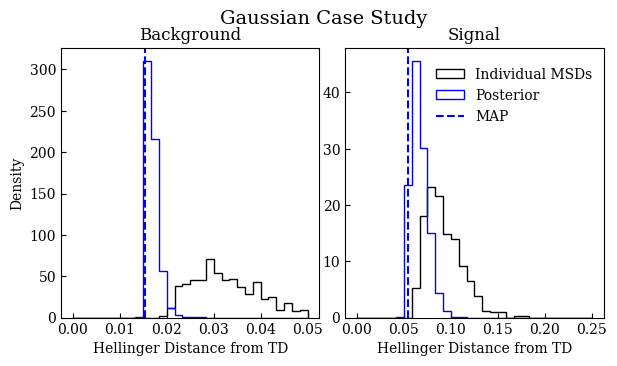

In [30]:
cmap = plt.cm.viridis

n_components = [2, 3, 4, 5, 6, 7, 8, 9, 10]
colors = [cmap(0.15 + 0.75 * i / (len(n_components) - 1)) for i in range(len(n_components))]
exponential_colors = colors
lin_colors = colors

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'wspace': 0.1})
fig.suptitle("Gaussian Case Study", fontsize=14, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
axs[0].hist(background_prior_hellingers, range=(0, .05), density=1, histtype='step', bins=30, color='k')#, label='Individual MSDs')
axs[0].hist(background_hellingers, range=(0, .05), density=1, histtype='step', bins=30, color='b', label=f'$M=6$')
axs[1].hist(signal_prior_hellingers, range=(0,.25), density=1, histtype='step', bins=30, color='k', label='Individual MSDs')
axs[1].hist(signal_hellingers, range=(0, .25), density=1, histtype='step', bins=30, color='b', label=f'Posterior')
axs[0].axvline(background_hellingers[0], color='b', linestyle='--')
axs[1].axvline(signal_hellingers[0], color='b', linestyle='--', label='MAP')
axs[0].set_title("Background", fontsize=12)
axs[1].set_title("Signal", fontsize=12)
axs[0].set_xlabel("Hellinger Distance from TD", fontsize=10)
axs[1].set_xlabel("Hellinger Distance from TD", fontsize=10)
axs[0].set_ylabel("Density", fontsize=10)
axs[0].tick_params(axis='both', which='both', direction='in')
axs[1].tick_params(axis='both', which='both', direction='in')
axs[1].legend(loc=(0.33, .7), fontsize=10, frameon=False)#
fig.savefig('figs/hellinger_gaussian_topics.pdf')
plt.show()
 

## DiHiggs

### Data distribution @di-Higgs

In [32]:
Ns = 500
Nb = 5000
rseed = 0
plotit = 0
mybinning = [np.linspace(110,140,11),np.linspace(110,140,11)] #fiduciary region only
mybinning_extended = [np.linspace(100,150,11),np.linspace(100,150,11)] # extended region
X, sd_signal, sd_background, pi_true_in_fiduciary = generate_sd_physical(Ns, Nb, mybinning=mybinning_extended, rseed=rseed, plotit=plotit)


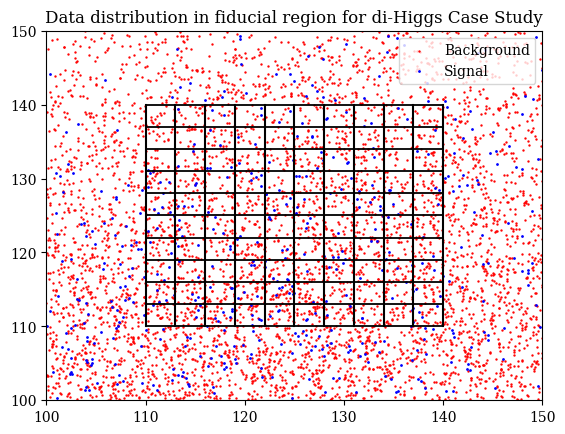

In [33]:
plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5, color='red', label='Background')
plt.scatter(sd_signal['x0'],sd_signal['x1'], s=1, color='blue', label='Signal')
plt.xlim(mybinning_extended[0][0],mybinning_extended[0][-1])
plt.ylim(mybinning_extended[1][0],mybinning_extended[1][-1])
for hline in mybinning[1]:
    plt.plot([mybinning[0][0],mybinning[0][-1]], [hline, hline], linewidth=1.3, linestyle='solid', color='black')
for vline in mybinning[1]:
    plt.plot([vline,vline],[mybinning[1][0],mybinning[1][-1]], linewidth=1.5, linestyle='solid', color='black')
plt.title('Data distribution in fiducial region for di-Higgs Case Study')
plt.legend(loc=1)
fig.savefig('figs/data_distribution_dihiggs.pdf', bbox_inches='tight', pad_inches=0.2)

plt.show()

### Kappa distribution @di-Higgs

In [34]:
K2 = 20
fname = f"results/pi_collection-dihiggs-model.fiduciary-20-topics-varying.20260320_104408rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_20 = pickle.load(f)

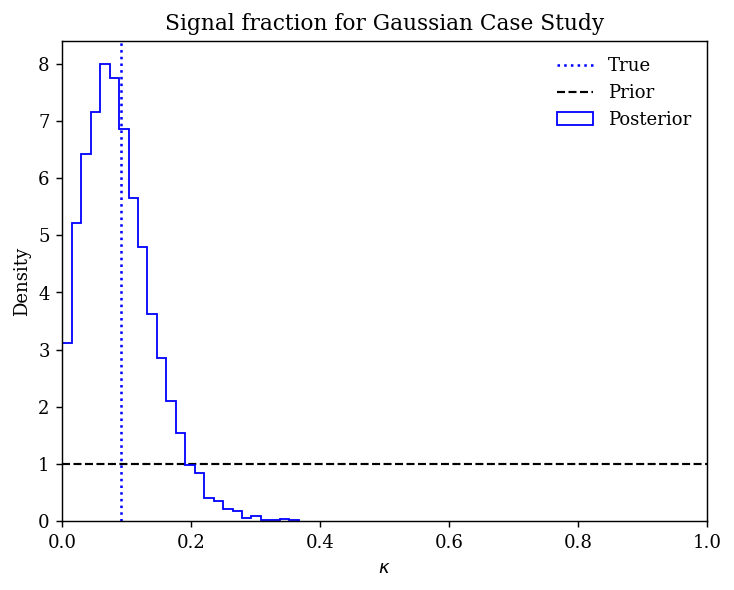

In [35]:
pi_true = 5000/55000
plt.figure(dpi=130)
plt.axvline(x=pi_true, color='blue', linestyle='dotted', linewidth=1.4, label='True', zorder=0)
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1.2, label='Prior', zorder = 1)
plt.hist(pi_collection_20[5]['pi'], bins=25, histtype='step', density=1, color='blue', label='Posterior', zorder=2)
plt.xlim(0,1)
plt.xlabel('$\\kappa$')
plt.ylabel('Density')
plt.title('Signal fraction for Gaussian Case Study') 
plt.legend(frameon=False)
plt.savefig('figs/signal-fraction_dihiggs.pdf')
#plt.yticks([])
plt.show()

### Signal and Background 2D histograms @di-Higgs

In [36]:
Ns = 30000
Nb = 200000
rseed = 0
plotit = 0
mybinning = [np.linspace(110,140,11),np.linspace(110,140,11)] #fiduciary region only
X, sd_signal, sd_background, pi_true_in_fiduciary = generate_sd_physical(Ns, Nb, mybinning=mybinning, rseed=rseed, plotit=plotit)


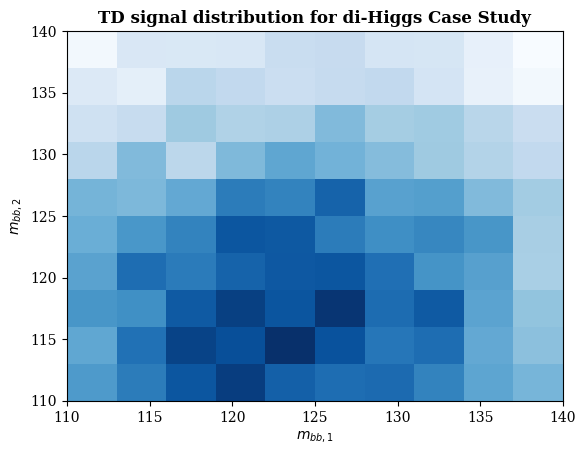

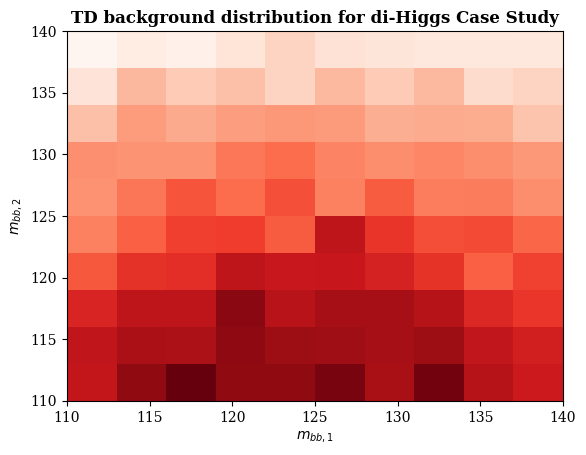

In [37]:
mybins = np.linspace(110,140,10)
mybins = mybinning
# Plot 2D histogram for df_s
plt.hist2d(sd_signal['x0'], sd_signal['x1'], bins=mybins, cmap='Blues')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('$m_{bb,1}$')
plt.ylabel('$m_{bb,2}$')
plt.title('TD signal distribution for di-Higgs Case Study', fontweight='bold', fontsize=12)
plt.savefig('figs/TD_signal_distribution_dihiggs.pdf')
plt.show()

# Plot 2D histogram for df_b
plt.hist2d(sd_background['x0'], sd_background['x1'], bins=mybins, cmap='Reds')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('$m_{bb,1}$')
plt.ylabel('$m_{bb,2}$')
plt.title('TD background distribution for di-Higgs Case Study', fontweight='bold', fontsize=12)
plt.savefig('figs/TD_background_distribution_dihiggs.pdf')
plt.show()

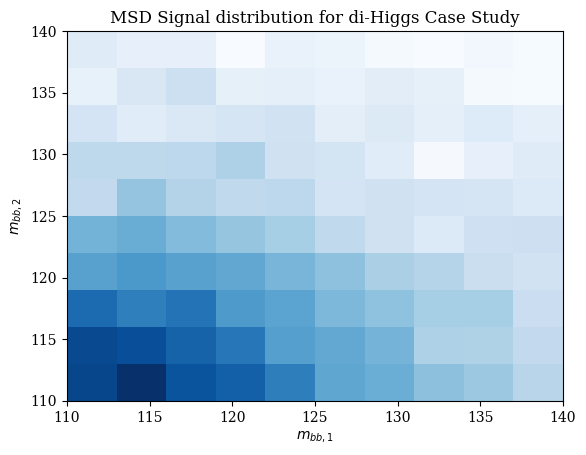

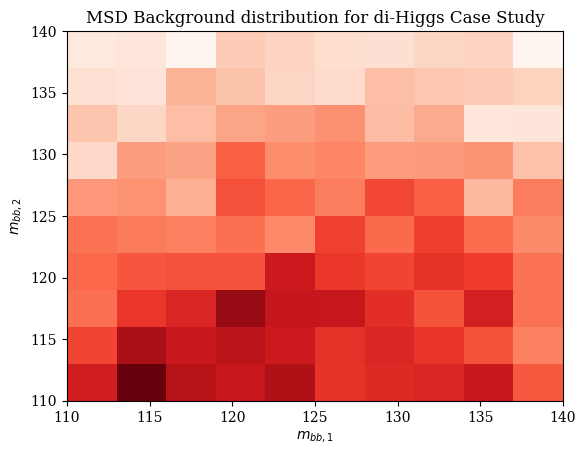

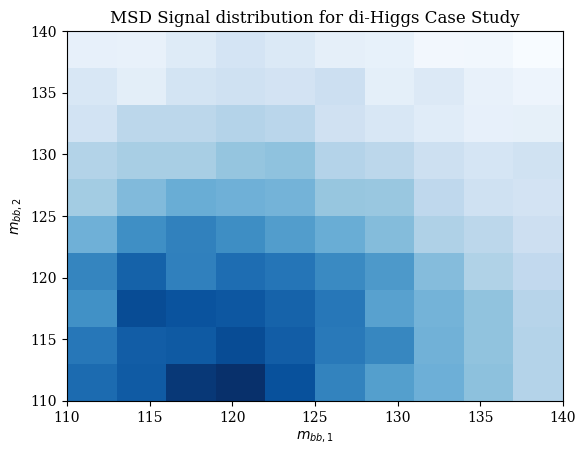

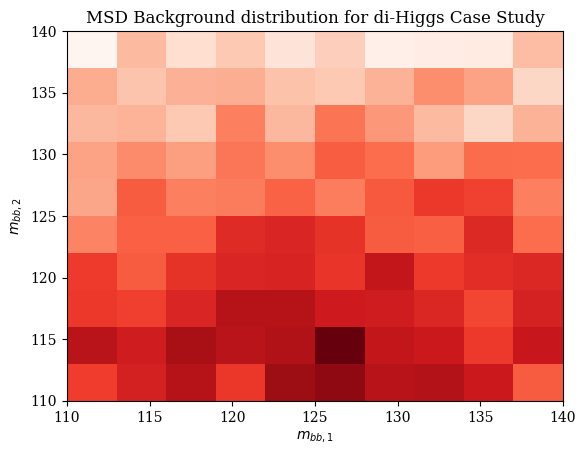

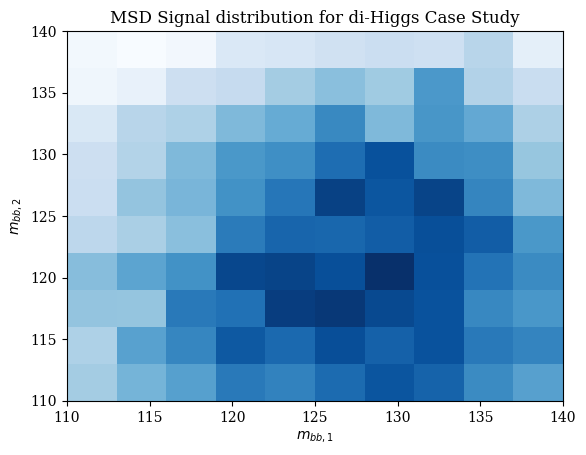

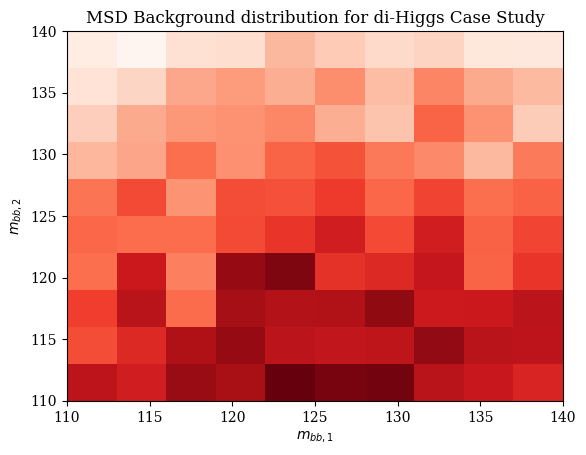

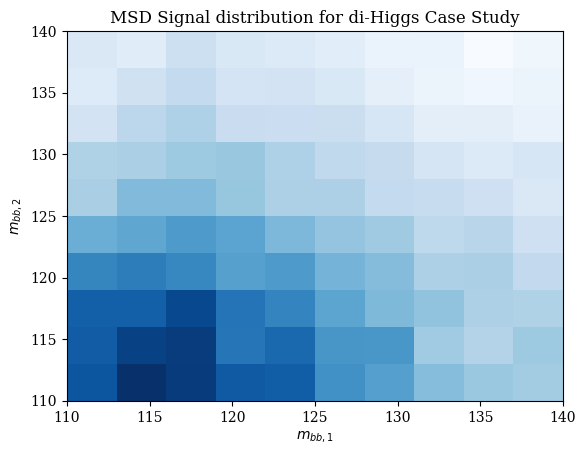

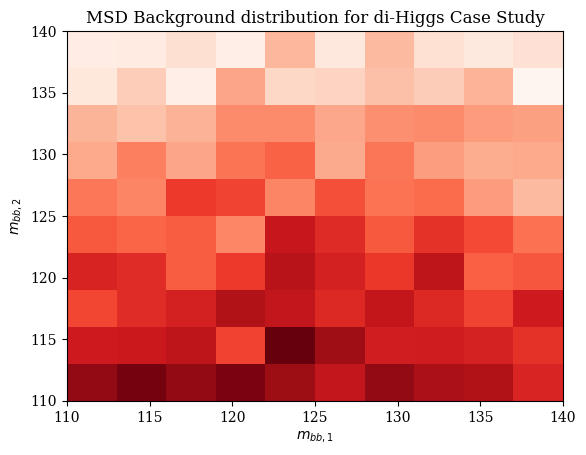

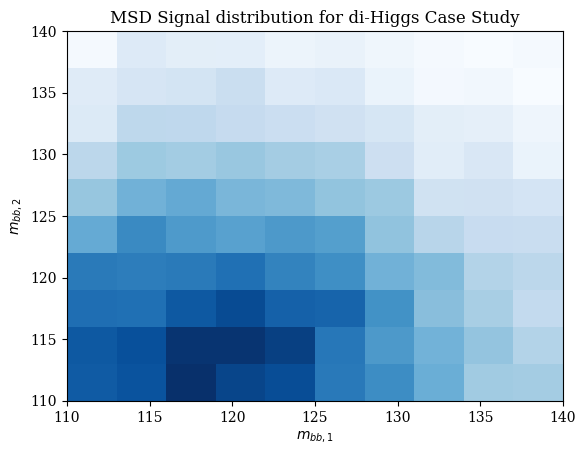

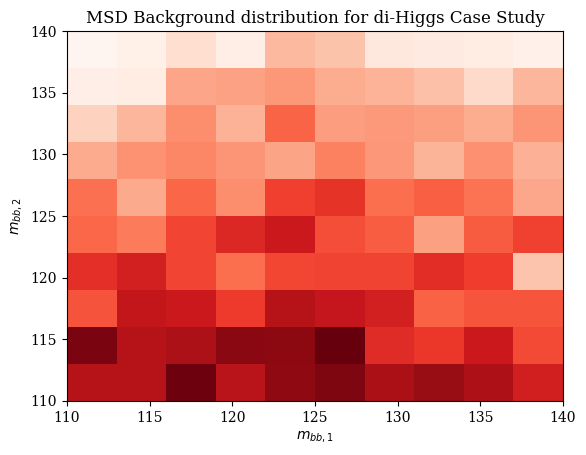

In [38]:
i=0
mybins = mybinning
for n in range(1,6):
    ssd_length=100000
    path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
    ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    ts = ts[:ssd_length]
    path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'   
    tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    tb = tb[:ssd_length]
    
    # Plot 2D histogram for df_s
    counts = plt.hist2d(ts['x0'], ts['x1'], bins=mybins,cmap='Blues')
    plt.xlim(110,140)
    plt.ylim(110,140)
    #plt.colorbar(label='Count')
    plt.xlabel('$m_{bb,1}$')
    plt.ylabel('$m_{bb,2}$')
    plt.title('MSD Signal distribution for di-Higgs Case Study')
    plt.savefig('figs/MSD_signal_distribution-'+str(i)+'_dihiggs.pdf')
    plt.show()
    
    # Plot 2D histogram for df_b
    countb = plt.hist2d(tb['x0'], tb['x1'], bins=mybins, cmap='Reds')
    plt.xlim(110,140)
    plt.ylim(110,140)
    #plt.colorbar(label='Count')
    plt.xlabel('$m_{bb,1}$')
    plt.ylabel('$m_{bb,2}$')
    plt.title('MSD Background distribution for di-Higgs Case Study')
    plt.savefig('figs/MSD_background_distribution-'+str(i)+'_dihiggs.pdf')
    plt.show()
    
    i+=1

### Coverage plot @di-Higgs

In [39]:
K2 = 4
fname = f"results/pi_collection-dihiggs-model.fiduciary-4-topics-varying.20260320_122640rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_4 = pickle.load(f)

In [40]:
K2 = 20
fname = f"results/pi_collection-dihiggs-model.fiduciary-20-topics-varying.20260320_104408rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_20_seed_1 = pickle.load(f)


In [41]:
K2 = 50
fname = f"results/pi_collection-dihiggs-model.fiduciary-50-topics-varying.20260320_122728rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_50 = pickle.load(f)

In [42]:
K2 = 100
fname = f"results/pi_collection-dihiggs-model.fiduciary-100-topics-varying.20260320_123017rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_100 = pickle.load(f)

In [43]:
cmap = plt.cm.viridis
n_components = [2,3,4,5,6,7,8]
colors = [cmap(0.15 + 0.75 * i / (len(n_components) - 1)) for i in range(len(n_components))]

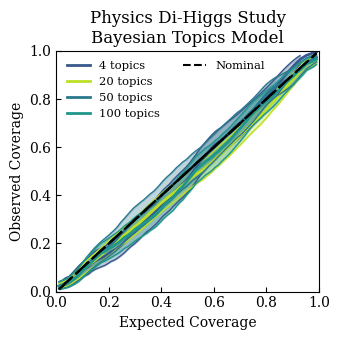

In [44]:
plt.rcParams.update({'text.usetex': False, 'font.family': 'serif'})
pi_true = 0.09090909090909091
fig, axes = plt.subplots(figsize=(3.5,3.5), dpi=100)
# 4 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_4, pi_true)
i = 1  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='4 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

#20 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_20, pi_true)
i = 6  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='20 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)


#50 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_50, pi_true)
i = 2  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='50 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

#100 topics
x, mean_y, lower_y, upper_y = create_curves(pi_collection_100, pi_true)
i = 3  # change this index as needed
plt.plot(x, mean_y, color=colors[i], linewidth=2, label='100 topics')
plt.plot(x, lower_y, color=colors[i], linewidth=1)
plt.plot(x, upper_y, color=colors[i], linewidth=1)
plt.plot(x,x, color='black',  linestyle=(0, (8, 3)))
plt.fill_between(x, lower_y, upper_y, color=colors[i], alpha=0.3)

# final details
plt.plot(x, x, color='black', linestyle='dashed', label='Nominal')
plt.xlim(0,1); plt.ylim(0,1)
plt.xticks([0.0,0.2,0.4,0.6,0.8,1.0])
plt.xlabel('Expected Coverage'); plt.ylabel('Observed Coverage')
plt.gca().tick_params(axis='both', which='both', direction='in')
#axes = plt.gca()

axes.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes.set_ylabel("Observed Coverage")
axes.set_xlabel("Expected Coverage")
axes.tick_params(axis='both', which='both', direction='in')
handles, labels = axes.get_legend_handles_labels()
blank = mpatches.Patch(color='none', label='')
handles += [blank] * 2
labels += [''] * 2
axes.legend(handles, labels, ncol=2, frameon=False, fontsize='small')

plt.title('Physics Di-Higgs Study\nBayesian Topics Model')
plt.tight_layout()
fig.savefig('figs/coverage_dihiggs.topics.pdf', bbox_inches='tight', pad_inches=0.2)

plt.show()

### kappa pull-sigma for true = fixed = 0.09 @di-Higgs

In [45]:
K2 = 20
fname = f"results/pi_collection-dihiggs-model.fiduciary-20-topics-varying.20260320_104408rseed=1.pickle"
with open(fname, 'rb') as f:
    pi_collection_10_seed_1 = pickle.load(f)
print(len(pi_collection_10_seed_1))

600


In [46]:
pi_true = 5000 / 55000
out = []
for i in range(len(pi_collection_10_seed_1)):
    tmp = list(credible_interval_hdi(pi_collection_10_seed_1[i]['pi'],0.68))
    hdi68 = tmp[1]-tmp[0]
    tmp = list(credible_interval_hdi(pi_collection_10_seed_1[i]['pi'],0.10))
    map_marginalized = (tmp[1]+tmp[0])/2
    map_full = pi_collection_10_seed_1[i].iloc[0]['pi']
    pull = (map_full - pi_true) / (hdi68/2)
    pull2 = (map_marginalized - pi_true) / (hdi68/2)
    out.append([hdi68, map_marginalized, map_full, pull, pull2])

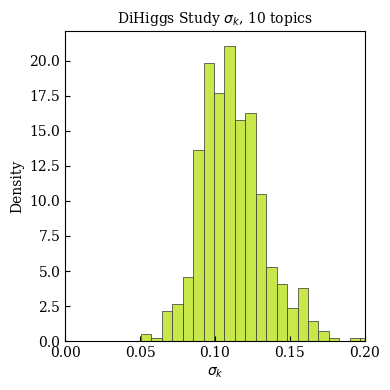

In [47]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.hist([x[0] for x in out], bins=25, color='#c7e74a', edgecolor='#333333', linewidth=0.5, density=True)
#ax.axvline(0.03, color='k', linestyle='--', linewidth=1.5)  # change 0.03 if needed

ax.set_xlabel(r'$\sigma_k$')
ax.set_ylabel('Density')
ax.set_title('DiHiggs Study $\\sigma_k$, 10 topics', fontsize=10)
ax.tick_params(axis='both', which='both', direction='in')
ax.set_xlim(0, 0.2)
#ax.set_yticks([])  

plt.tight_layout()
#plt.savefig('figs/dihiggs_uncertainties.topicsmodel.pdf')
plt.show()

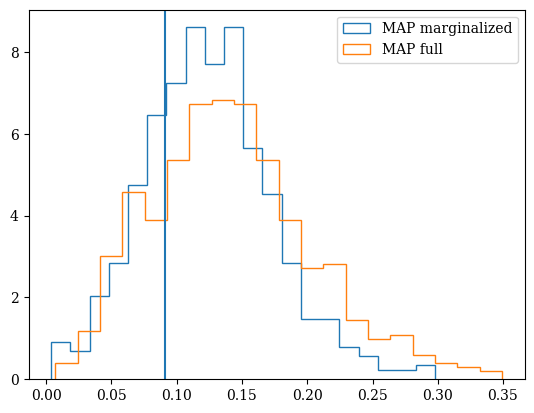

In [48]:
plt.hist([x[1] for x in out], histtype='step', density=1, bins=20, label='MAP marginalized')
plt.hist([x[2] for x in out], histtype='step', density=1, bins=20, label='MAP full')
plt.axvline(pi_true)
plt.legend()
plt.show()

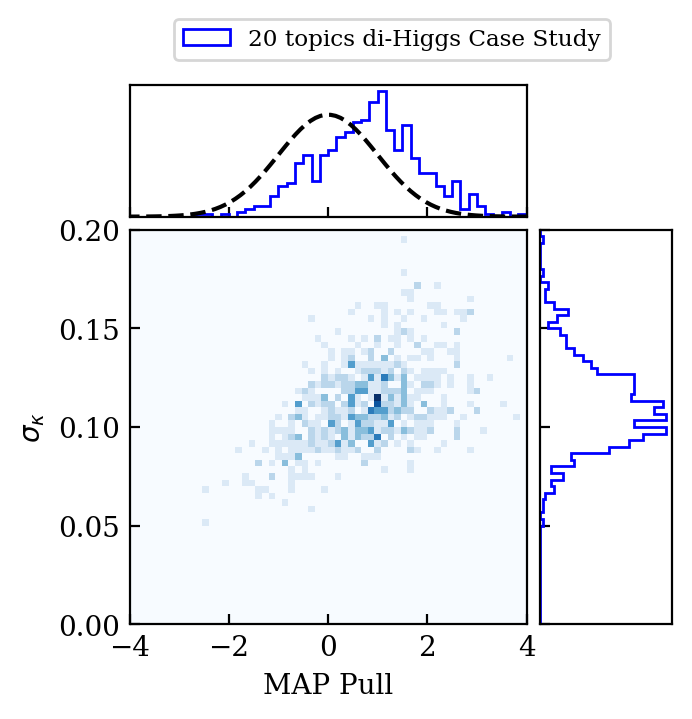

In [49]:
# Sample data

cmap = plt.cm.Blues.copy()
cmap.set_under("white")

x = [x[3] for x in out]
y = [x[0] for x in out]
# x_baseline = (torch.stack(baseline_consolidated_preds_list).flatten().numpy()-0.1)/torch.stack(baseline_consolidated_uncs_list).flatten().numpy()
# y_baseline = torch.stack(baseline_consolidated_uncs_list).flatten().numpy()

fig, axs = plt.subplot_mosaic(
    [["histx", "."],
     ["joint", "histy"]],
        figsize=(3.5, 3.5),
    width_ratios=[3, 1],
    height_ratios=[1, 3],
    gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    dpi=200
)

# 2D histogram

axs["joint"].hist2d(x, y, bins=60, cmap=cmap, range=[[-4, 4], [0, 0.2]])
axs["joint"].set_xlabel("MAP Pull")
axs["joint"].set_ylabel(f"$\sigma_\kappa$")
axs["joint"].tick_params(which='both', direction='in')

# Marginals
axs["histx"].hist(x, bins=60, color="blue", range=(-5, 5), density=True, histtype='step', label=f"{K2} topics di-Higgs Case Study")#\nTrue = 0.09 (fixed)")
#axs["histx"].hist(x_baseline, bins=60, color="black", range=(-5, 5), density=True, label="Baseline", histtype='step')
axs["histx"].plot(np.linspace(-5, 5, 100), norm.pdf(np.linspace(-5, 5, 100)), color="black", linestyle="--")#, label="Standard Normal")
axs["histx"].sharex(axs["joint"])
axs["histx"].tick_params(labelbottom=False, direction='in')
axs["histx"].set_yticks([])

axs["histy"].hist(y, bins=60, orientation="horizontal", color="blue", range=(0, 0.2), density=True, histtype='step')
#axs["histy"].hist(y_baseline, bins=60, orientation="horizontal", color="black", range=(0, 0.15), density=True, label="Baseline", histtype='step')

axs["histy"].sharey(axs["joint"])
axs["histy"].tick_params(labelleft=False, direction='in')
axs["histy"].set_xticks([])

handles, labels = axs["histx"].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, .9), fontsize='small', columnspacing=1.0)

fig.savefig('figs/pull-sigma_dihiggs.pdf', bbox_inches='tight', pad_inches=0.2)

plt.show()

 



### kappa pull-sigma for true ~ prior @dihiggs

In [50]:
K2 = 20#
fname = f"results/pi_collection-dihiggs-model.fiduciary-20-varying-topics.unbiased-parameter-estimation.20260320_133109rseed=1.pickle" # k=20
with open(fname, 'rb') as f:
    pi_collection_20_seed_1 = pickle.load(f)

print(len(pi_collection_20_seed_1))

1000


In [51]:
out = []
for i in range(len(pi_collection_20_seed_1)):
    pi_true = pi_collection_20_seed_1[i][1]
    tmp = list(credible_interval_hdi(pi_collection_20_seed_1[i][0]['pi'],0.68))
    hdi68 = tmp[1]-tmp[0]
    tmp = list(credible_interval_hdi(pi_collection_20_seed_1[i][0]['pi'],0.10))
    map_marginalized = (tmp[1]+tmp[0])/2
    map_full = pi_collection_20_seed_1[i][0].iloc[0]['pi']
    pull = (map_full - pi_true) / (hdi68/2)
    pull2 = (map_marginalized - pi_true) / (hdi68/2)
    out.append([hdi68, map_marginalized, map_full, pull, pull2])

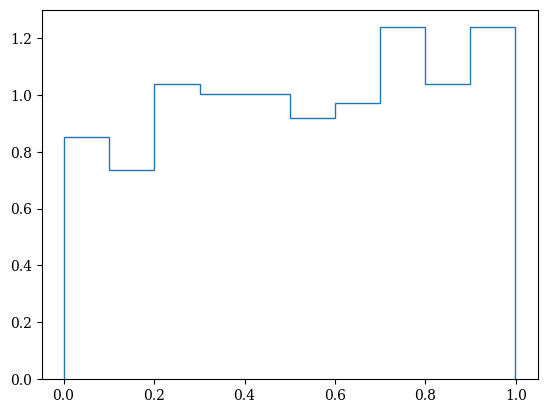

In [52]:
plt.hist([pi_collection_20_seed_1[i][1] for i in range(len(pi_collection_10_seed_1))], density=1, histtype='step')
plt.show()

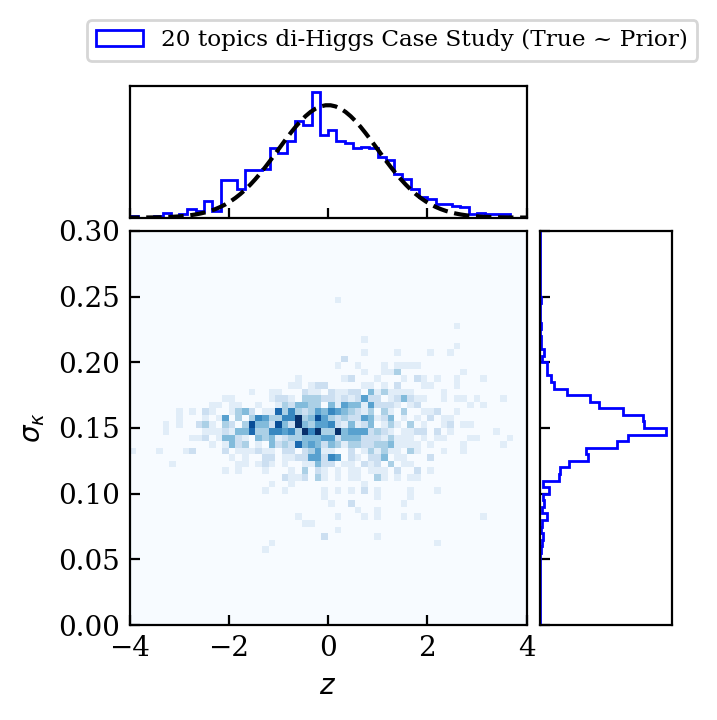

In [53]:
# Sample data

cmap = plt.cm.Blues.copy()
cmap.set_under("white")

x = [x[3] for x in out]
y = [x[0] for x in out]
# x_baseline = (torch.stack(baseline_consolidated_preds_list).flatten().numpy()-0.1)/torch.stack(baseline_consolidated_uncs_list).flatten().numpy()
# y_baseline = torch.stack(baseline_consolidated_uncs_list).flatten().numpy()

fig, axs = plt.subplot_mosaic(
    [["histx", "."],
     ["joint", "histy"]],
        figsize=(3.5, 3.5),
    width_ratios=[3, 1],
    height_ratios=[1, 3],
    gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    dpi=200
)

# 2D histogram

axs["joint"].hist2d(x, y, bins=60, cmap=cmap, range=[[-4, 4], [0, 0.3]])
axs["joint"].set_xlabel("$z$")
axs["joint"].set_ylabel(f"$\sigma_\kappa$")
axs["joint"].tick_params(which='both', direction='in')

# Marginals
axs["histx"].hist(x, bins=60, color="blue", range=(-5, 5), density=True, histtype='step', label=f"{K2} topics di-Higgs Case Study (True ~ Prior)")
#axs["histx"].hist(x_baseline, bins=60, color="black", range=(-5, 5), density=True, label="Baseline", histtype='step')
axs["histx"].plot(np.linspace(-5, 5, 100), norm.pdf(np.linspace(-5, 5, 100)), color="black", linestyle="--")#, label="Standard Normal")
axs["histx"].sharex(axs["joint"])
axs["histx"].tick_params(labelbottom=False, direction='in')
axs["histx"].set_yticks([])

axs["histy"].hist(y, bins=60, orientation="horizontal", color="blue", range=(0, 0.3), density=True, histtype='step')
#axs["histy"].hist(y_baseline, bins=60, orientation="horizontal", color="black", range=(0, 0.15), density=True, label="Baseline", histtype='step')

axs["histy"].sharey(axs["joint"])
axs["histy"].tick_params(labelleft=False, direction='in')
axs["histy"].set_xticks([])

handles, labels = axs["histx"].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, .9), fontsize='small', columnspacing=1.0)

fig.savefig('figs/pull-sigma_dihiggs.true-prior.pdf', bbox_inches='tight', pad_inches=0.2)

plt.show()

 



### Hellinger distances dihiggs

In [54]:
K2 = 20
fname = f"results/hellinger-data-dihiggs-20-topics.20260320_104408rseed=1.pickle"
with open(fname, 'rb') as f:
    hellinger_distances = pickle.load(f)

In [55]:
[sd_signal, sd_background, mybinning, samples_unmix, Ys, Yb] = hellinger_distances
V = (len(mybinning[0])-1)*(len(mybinning[1])-1)

In [56]:
signal_true = normalize_prob(flat_histogramdd(sd_signal,mybinning))
background_true = normalize_prob(flat_histogramdd(sd_background,mybinning))

# Posterior Hellinger distances to true
signal_hellingers = []
background_hellingers = []
for draw in range(len(samples_unmix)):
    tmp_s = []
    tmp_b = []
    for j in range(1,V+1):
        tmp_s.append(samples_unmix.iloc[draw]['phi_signal.'+str(j)])
        tmp_b.append(samples_unmix.iloc[draw]['phi_background.'+str(j)])
    signal_draw = np.array(tmp_s)
    background_draw = np.array(tmp_b)
    signal_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(signal_true)-np.sqrt(signal_draw))**2)))
    background_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(background_true)-np.sqrt(background_draw))**2)))

# Prior Hellinger distances to true
signal_prior_hellingers = []
background_prior_hellingers = []
for ssd in range(len(Ys)):
    #signal_prior_hellingers.append(np.sum((np.sqrt(signal_true)-np.sqrt(Ys[ssd]))**2))
    signal_prior_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(signal_true) - np.sqrt(Ys[ssd]))**2)))
for ssd in range(len(Yb)):
    background_prior_hellingers.append(np.sqrt(0.5 * np.sum((np.sqrt(background_true)-np.sqrt(Yb[ssd]))**2)))


/tmp/ipykernel_364359/1529123848.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


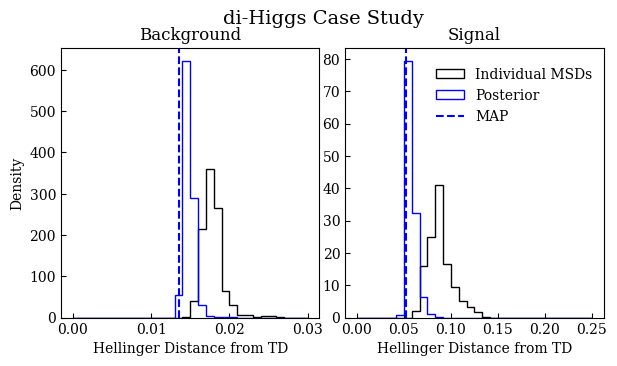

In [57]:
cmap = plt.cm.viridis

n_components = [2, 3, 4, 5, 6, 7, 8, 9, 10]
colors = [cmap(0.15 + 0.75 * i / (len(n_components) - 1)) for i in range(len(n_components))]
exponential_colors = colors
lin_colors = colors

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'wspace': 0.1})
fig.suptitle("di-Higgs Case Study", fontsize=14, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
axs[0].hist(background_prior_hellingers, range=(0, .03), density=1, histtype='step', bins=30, color='k')#, label='Individual MSDs')
axs[0].hist(background_hellingers, range=(0, .03), density=1, histtype='step', bins=30, color='b', label=f'$M=6$')
axs[1].hist(signal_prior_hellingers, range=(0,.25), density=1, histtype='step', bins=30, color='k', label='Individual MSDs')
axs[1].hist(signal_hellingers, range=(0, .25), density=1, histtype='step', bins=30, color='b', label=f'Posterior')
axs[0].axvline(background_hellingers[0], color='b', linestyle='--')
axs[1].axvline(signal_hellingers[0], color='b', linestyle='--', label='MAP')
axs[0].set_title("Background", fontsize=12)
axs[1].set_title("Signal", fontsize=12)
axs[0].set_xlabel("Hellinger Distance from TD", fontsize=10)
axs[1].set_xlabel("Hellinger Distance from TD", fontsize=10)
axs[0].set_ylabel("Density", fontsize=10)
axs[0].tick_params(axis='both', which='both', direction='in')
axs[1].tick_params(axis='both', which='both', direction='in')
axs[1].legend(loc=(0.33, .7), fontsize=10, frameon=False)#
fig.savefig('figs/hellinger_dihiggs_topics.pdf')
plt.show()
 